# Rossmann Store Sales Prediction
Predicting the number of orders (Sales) for Rossmann stores across Germany.

**Model Used:** Linear Regression
**Dataset:** Rossmann Store Sales — Kaggle (1,017,209 rows across 1,115 stores)

**Key Challenge:** Sales data is time-series in nature — requires careful train/test splitting

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

## Loading the Dataset
Two separate files — `train.csv` contains sales records, `store.csv` contains store metadata.
Merging both on the `Store` column to get a unified dataset.

In [2]:
train = pd.read_csv("../Datasets/rossmann-store-sales/train.csv", low_memory=False)
store = pd.read_csv("../Datasets/rossmann-store-sales/store.csv")

In [3]:
print("Train shape:", train.shape)
train.head()

Train shape: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
print("Store shape:", store.shape)
store.head()

Store shape: (1115, 10)


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df = pd.merge(train, store, on="Store")
df.shape

(1017209, 18)

## Exploratory Data Analysis

In [7]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
df.shape

(1017209, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [10]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [11]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

## Null Value Analysis
Identifying missing values and deciding how to handle each column.

In [12]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [13]:
df.columns[df.isnull().any()]

Index(['CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear',
       'PromoInterval'],
      dtype='object')

In [14]:
df.isnull().sum()[df.isnull().sum() > 0]

CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

> Handling nulls column by column based on context:
> - `CompetitionDistance` → fill with **median** (skewed distribution, median is more robust than mean)
> - `CompetitionOpenSinceMonth/Year` and `Promo2Since` columns → fill with **0** (no competition/promo data = not applicable)
> - `PromoInterval` → fill with **"None"** (no promo interval = store not participating in Promo2)

In [15]:
df["CompetitionDistance"].median()

2330.0

In [16]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())

In [17]:
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

In [18]:
df["PromoInterval"].unique()

array([nan, 'Jan,Apr,Jul,Oct', 'Feb,May,Aug,Nov', 'Mar,Jun,Sept,Dec'],
      dtype=object)

In [19]:
df["PromoInterval"] = df["PromoInterval"].fillna("None")

In [20]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [21]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,None
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None


## Sales Distribution
Understanding how sales are spread. Filtering out closed store days (Sales = 0)
since they don't represent actual sales patterns.

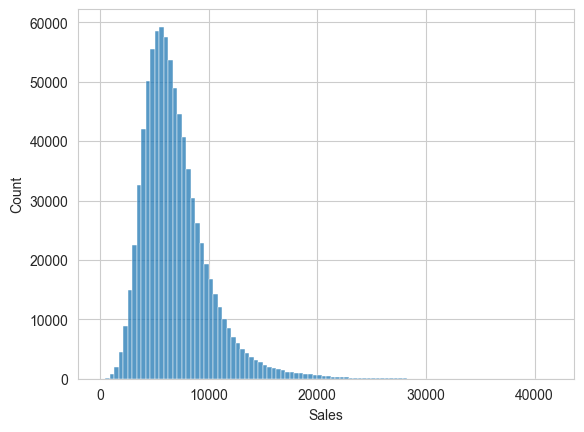

In [22]:
# How are Sales spread
data = df[df["Sales"] > 0]
sns.histplot(data=data, x="Sales", bins=100)
plt.show()

> Sales follow a roughly normal distribution when stores are open,
> centered around €5,000-6,000 per day.

## Top & Bottom 10 Stores by Average Sales

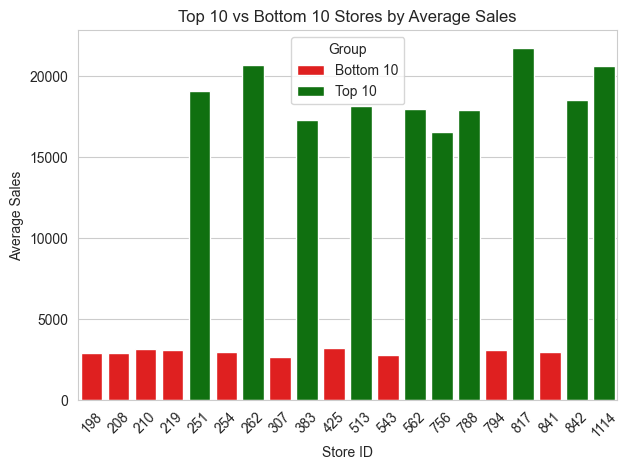

In [23]:
# Top 10 and Bottom 10 Stores by Average Sales — Combined View
filtered = df[df["Sales"] > 0]
store_avg = filtered.groupby("Store")["Sales"].mean().sort_values(ascending=False).reset_index()

top10 = store_avg.head(10).copy()
bottom10 = store_avg.tail(10).copy()

top10["Group"] = "Top 10"
bottom10["Group"] = "Bottom 10"

combined = pd.concat([top10, bottom10])

palette = {"Top 10": "green", "Bottom 10": "red"}

sns.barplot(x="Store", y="Sales", data=combined, hue="Group", palette=palette, dodge=False)
plt.title("Top 10 vs Bottom 10 Stores by Average Sales")
plt.xlabel("Store ID")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Effect of Closed Days on Sales Distribution
Comparing top 10 stores with and without days where Sales = 0 (store closed).
Including closed days artificially lowers the average — filtering gives a truer picture.

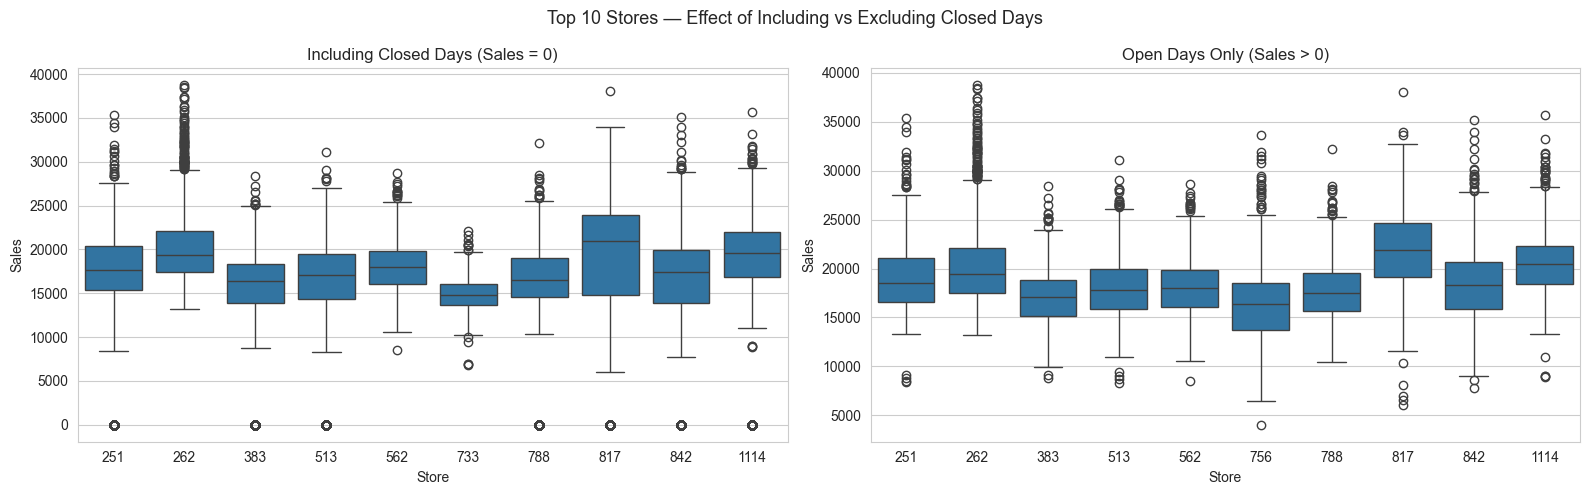

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data_all = df.groupby("Store")["Sales"].mean().sort_values(ascending=False).head(10).index
sns.boxplot(x="Store", y="Sales", data=df[df["Store"].isin(data_all)], ax=axes[0])
axes[0].set_title("Including Closed Days (Sales = 0)")

data_filtered = filtered.groupby("Store")["Sales"].mean().sort_values(ascending=False).head(10).index
sns.boxplot(x="Store", y="Sales", data=filtered[filtered["Store"].isin(data_filtered)], ax=axes[1])
axes[1].set_title("Open Days Only (Sales > 0)")

plt.suptitle("Top 10 Stores — Effect of Including vs Excluding Closed Days", fontsize=13)
plt.tight_layout()
plt.show()

> The left plot shows compressed distributions due to zero-sales days pulling averages down.
> The right plot gives a cleaner view of actual sales performance on trading days.
> From here on, `filtered` (Sales > 0) is used for all EDA visualizations.

## Sales by Store Type and Assortment

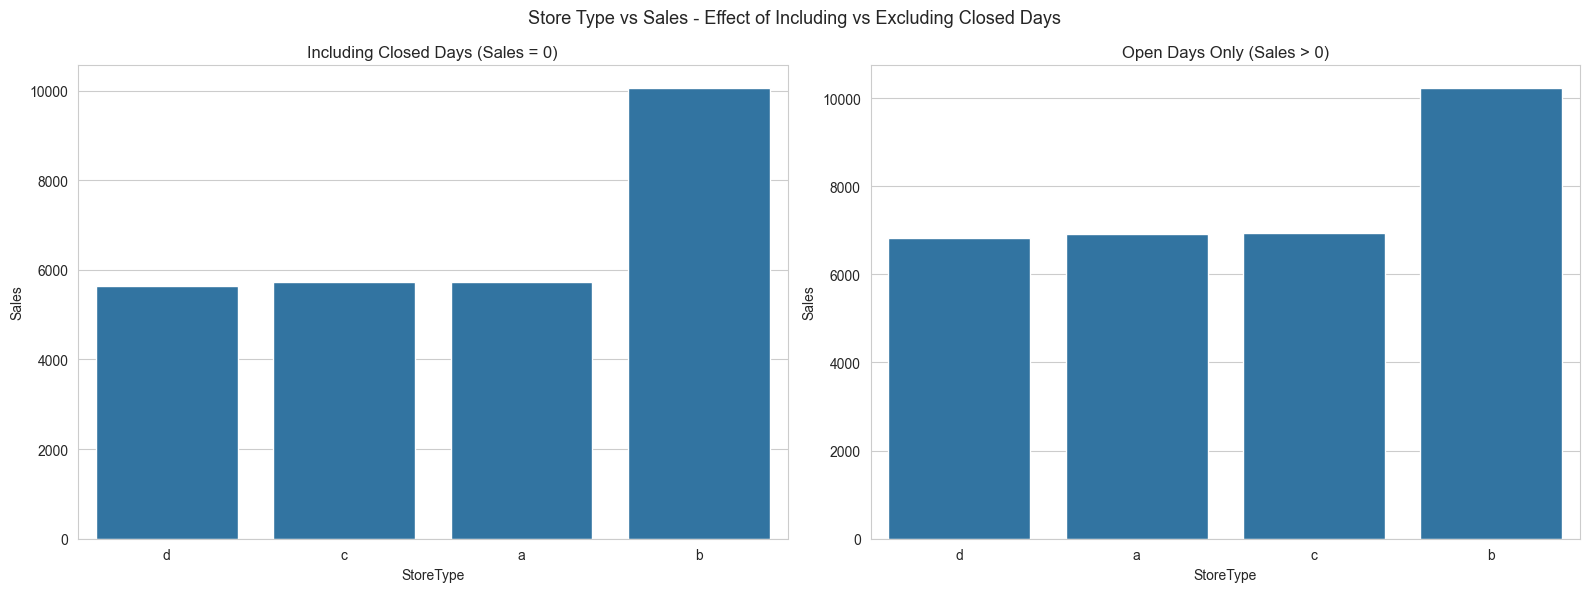

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

data_all = df.groupby("StoreType")["Sales"].mean().sort_values().reset_index()
sns.barplot(x="StoreType", y="Sales", data=data_all, ax=axes[0])
axes[0].set_title("Including Closed Days (Sales = 0)")

data_filtered = filtered.groupby("StoreType")["Sales"].mean().sort_values().reset_index()
sns.barplot(x="StoreType", y="Sales", data=data_filtered, ax=axes[1])
axes[1].set_title("Open Days Only (Sales > 0)")

plt.suptitle("Store Type vs Sales - Effect of Including vs Excluding Closed Days", fontsize=13)
plt.tight_layout()
plt.show()

> Store Type `b` significantly outperforms others in average daily sales.

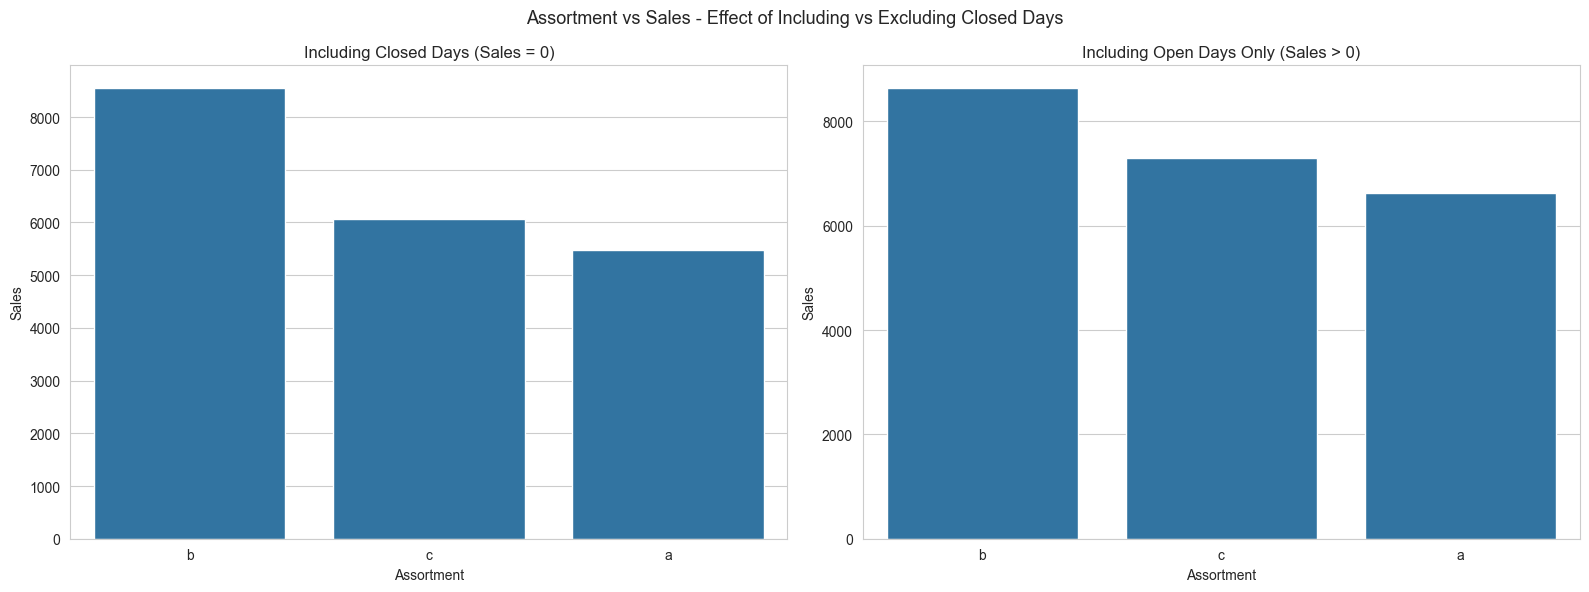

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

data_all = df.groupby("Assortment")["Sales"].mean().sort_values(ascending=False).reset_index()
sns.barplot(x="Assortment", y="Sales", data=data_all, ax=axes[0])
axes[0].set_title("Including Closed Days (Sales = 0)")

data_filtered = filtered.groupby("Assortment")["Sales"].mean().sort_values(ascending=False).reset_index()
sns.barplot(x="Assortment", y="Sales", data=data_filtered, ax=axes[1])
axes[1].set_title("Including Open Days Only (Sales > 0)")

plt.suptitle("Assortment vs Sales - Effect of Including vs Excluding Closed Days", fontsize=13)
plt.tight_layout()
plt.show()

> Assortment type `b` (extra) has the highest average sales,
> suggesting wider product range drives higher revenue.

## Effect of Promotions on Sales

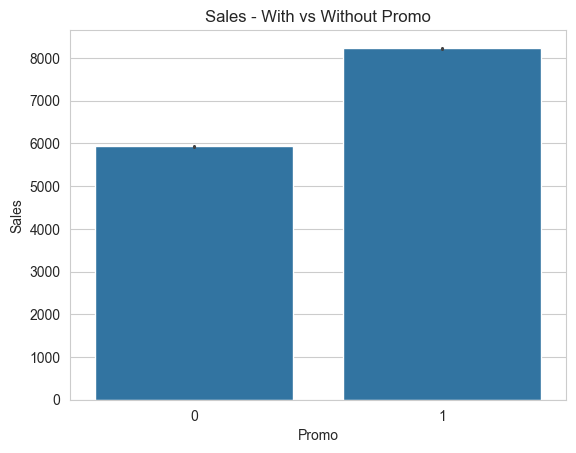

In [27]:
sns.barplot(x="Promo", y="Sales", data=filtered)
plt.title("Sales - With vs Without Promo")
plt.show()

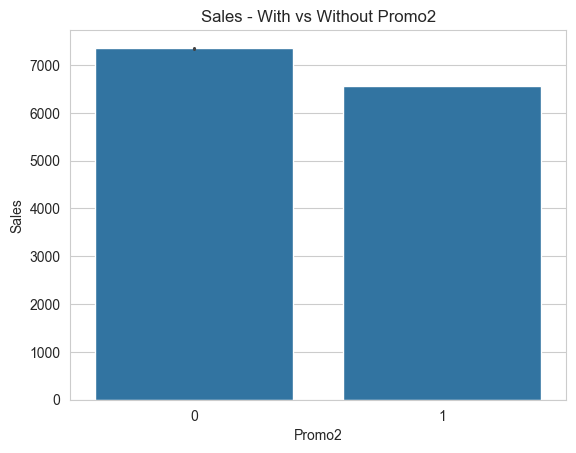

In [28]:
sns.barplot(x="Promo2", y="Sales", data=filtered)
plt.title("Sales - With vs Without Promo2")
plt.show()

> `Promo` (short-term promotions) shows a clear positive effect on sales.

> `Promo2` (continuous promotions) shows a weaker or slightly negative effect —
> possibly because ongoing discounts reduce perceived value over time.

## Sales by Day of Week and Month

In [29]:
df["DayOfWeek"].unique()

array([5, 4, 3, 2, 1, 7, 6], dtype=int64)

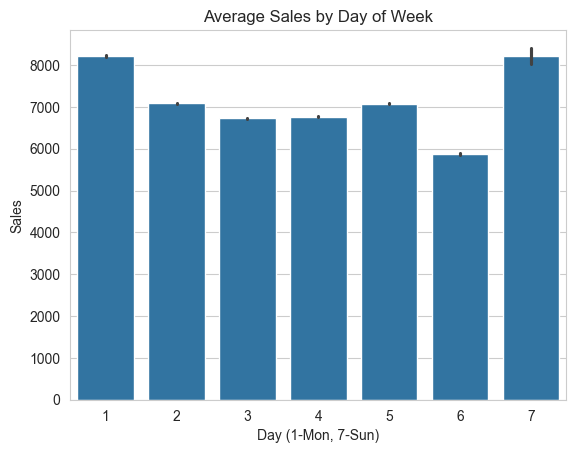

In [30]:
sns.barplot(x="DayOfWeek", y="Sales", data=filtered)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day (1-Mon, 7-Sun)")
plt.show()

> Sales peak mid-week and drop on weekends — Sunday (7) shows notably lower sales,
> likely due to reduced store hours or closures in Germany.

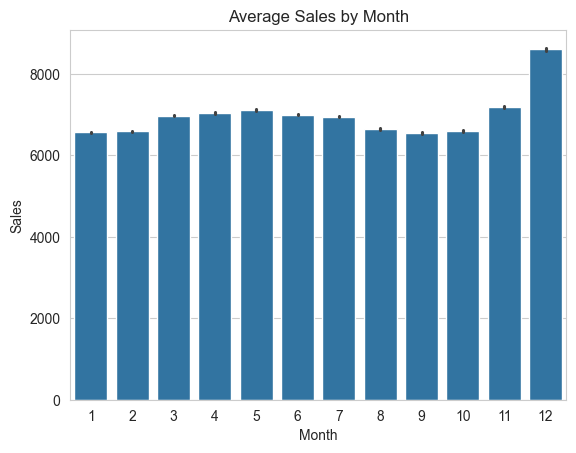

In [31]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
filtered = df[df["Sales"] > 0]  # recreate filtered AFTER datetime conversion refresh filtered after adding Month column

sns.barplot(x="Month", y="Sales", data=filtered)
plt.title("Average Sales by Month")
plt.show()

> Sales spike in November-December — consistent with holiday season shopping patterns.
> July also shows a slight dip, possibly due to summer holidays in Germany.

## Sales by Holiday Type

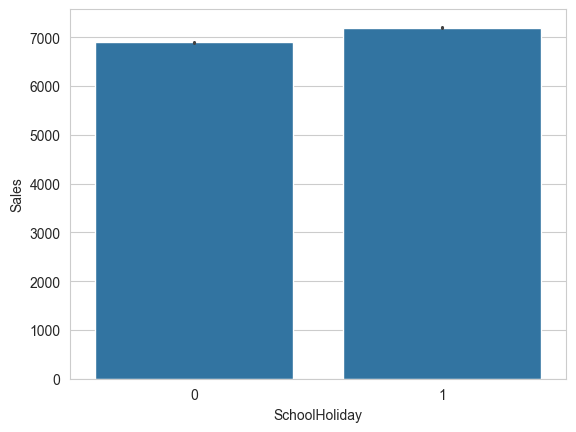

In [32]:
sns.barplot(x="SchoolHoliday", y="Sales", data=filtered)
plt.show()

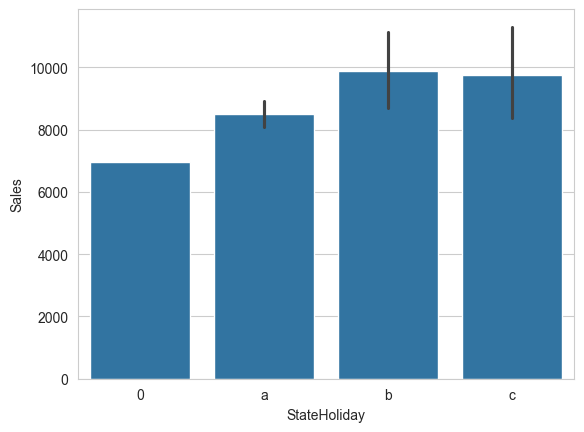

In [33]:
sns.barplot(x="StateHoliday", y="Sales", data=filtered)
plt.show()

> School holidays show minimal impact on sales.
> State holidays show a noticeable dip — most stores are closed or have reduced hours.

## Competition Distance vs Sales
Analyzing whether proximity to competitors affects sales.

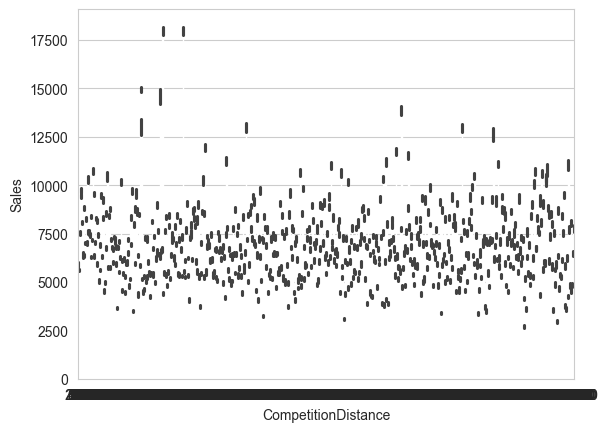

In [34]:
sns.barplot(x="CompetitionDistance", y="Sales", data=filtered)
plt.show()

 Direct barplot on raw CompetitionDistance — won't work as expected.

 CompetitionDistance is a continuous variable with thousands of unique values,
 so seaborn treats each distance as a separate category.

 Result: unreadable x-axis with one bar per value. Binning is needed first.

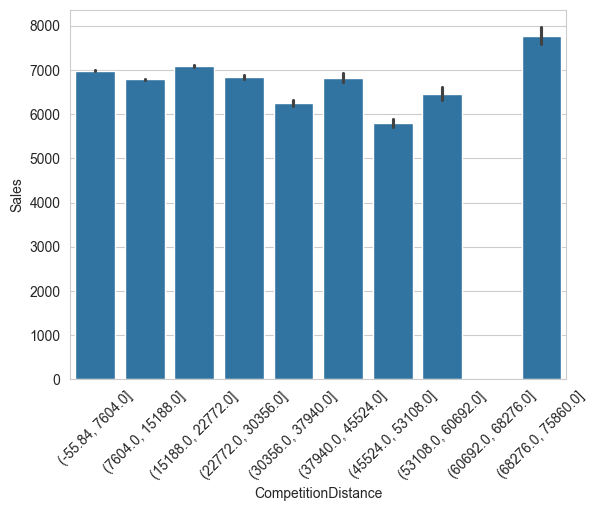

In [35]:
comp_data = filtered.copy()
comp_data["CompetitionDistance"] = pd.cut(comp_data['CompetitionDistance'], bins=10)
sns.barplot(x="CompetitionDistance", y="Sales", data=comp_data)
plt.xticks(rotation=45)
plt.show()

> No strong clear trend — stores very close to competitors don't necessarily
> have lower sales. Established stores may have loyal customer bases
> regardless of competitor proximity.

## Preprocessing
Keeping only open store days since closed days (Sales = 0) add noise without useful signal.

Dropping `Open` column after filtering (only value = 1 remains) and `Customers`
(not available at prediction time — including it would cause data leakage).

In [36]:
df = df[df["Open"] == 1].copy() # Keeping stores which are open
df.drop(columns=['Open', 'Customers'], inplace=True) # Dropping Open as only 1 exist

## Feature Engineering
Extracting time-based features from the `Date` column.

In [37]:
df["Year"] = df["Date"].dt.year
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [38]:
df.sample()

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Month,Year,WeekOfYear
401036,116,2,2014-07-08,5769,0,0,0,a,a,680.0,4.0,2013.0,0,0.0,0.0,None,7,2014,28


## Encoding Categorical Variables
Using **One-Hot Encoding** for `StoreType`, `Assortment`, `StateHoliday`, and `PromoInterval`.

OHE is preferred over Label Encoding here because these are **nominal categories**
(no inherent order between them). Label Encoding would imply a false ranking
(e.g. StoreType a=1 < b=2 < c=3) which could mislead the model.

In [ ]:
''' from sklearn.preprocessing import LabelEncoder
for col in ["StoreType", "Assortment", "StateHoliday" ,"PromoInterval"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    Using One Hot Encoding to get slightly better results '''

In [39]:
cols = ["StoreType", "Assortment", "StateHoliday", "PromoInterval"]
df = pd.get_dummies(df, columns=cols, drop_first=True)

## Train/Test Split — Time Based
Since this is sales time-series data, a **random split would leak future data into training**.
Instead, we sort by date and use the first 80% of time as training, last 20% as test.
This simulates a real forecasting scenario where the model predicts future sales.

In [ ]:
''' from sklearn.model_selection import train_test_split
X = df.drop(columns="Sales")
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 doing time based split with Date col '''

In [40]:
df = df.sort_values(by="Date")
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(columns="Sales")
y_train = train_df["Sales"]

X_test = test_df.drop(columns="Sales")
y_test = test_df["Sales"]

In [41]:
X_train = X_train.drop(columns="Date")
X_test = X_test.drop(columns="Date")

## Model Training — Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Model Evaluation

In [43]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Root Mean Squared Error:  {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Root Mean Squared Error:  2695.9701
R2 Score: 0.2256


> R² of 0.226 indicates Linear Regression explains only ~22% of sales variance.
> Sales patterns are driven by complex non-linear interactions (promotions × store type × seasonality)
> that LR cannot model effectively.
>
> **Baseline established.** Performance can be significantly improved using
> ensemble methods like Random Forest or XGBoost — to be explored as I progress further in ML.

## Actual vs Predicted Sales

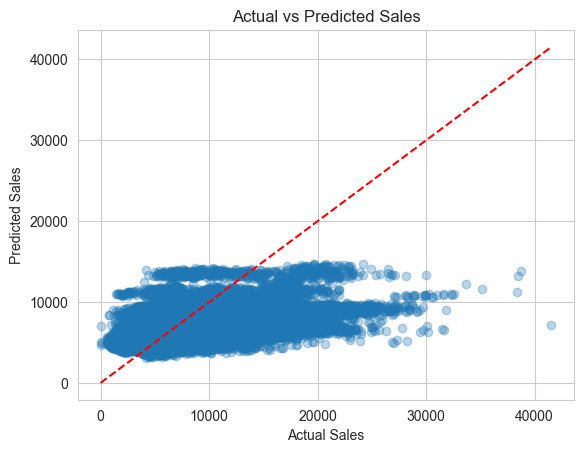

In [44]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

> The wide scatter around the red line confirms the model's limited accuracy.
> Predictions cluster in a narrow band while actual sales vary widely —
> indicating the model is missing key non-linear patterns.

## Residual Plot
A residual plot shows the difference between actual and predicted values against predictions — if the model is good, residuals should scatter randomly around zero with no pattern.

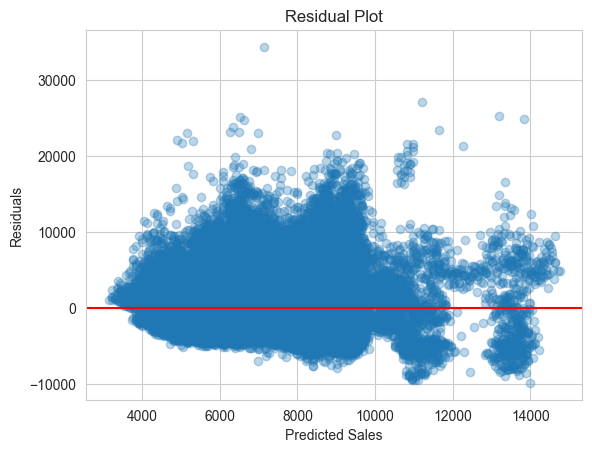

In [45]:
residue = y_test - y_pred
plt.scatter(y_pred, residue, alpha=0.3)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

> Residuals are not randomly scattered around zero — there's a clear pattern,
> which confirms the model is not capturing all the structure in the data.
> A well-fitted model would show residuals randomly distributed around the red line.

## Conclusion
- Linear Regression achieved an R² of **0.226** — a low but expected result for complex sales data
- **Promotions, Store Type, and Day of Week** were the most influential features based on EDA
- Sales data has strong non-linear and interaction effects that LR cannot capture
- Time-based train/test split was used to simulate real forecasting conditions
- **Next step:** Revisit with Random Forest or XGBoost for significantly better accuracy